# Titanic Survival Prediction

This notebook builds a **neural network** to predict survival on the Titanic. We use a **leak-free pipeline**: split first, then impute, encode, and scale using **training data only**.

## 1. Load data & explore

Load the dataset and inspect columns and shape.

In [1]:
import pandas as pd
df = pd.read_csv('titanic.csv')

### 1.1 Exploratory data analysis (EDA)

Charts below: target balance, survival by key features, and correlation of numeric predictors.

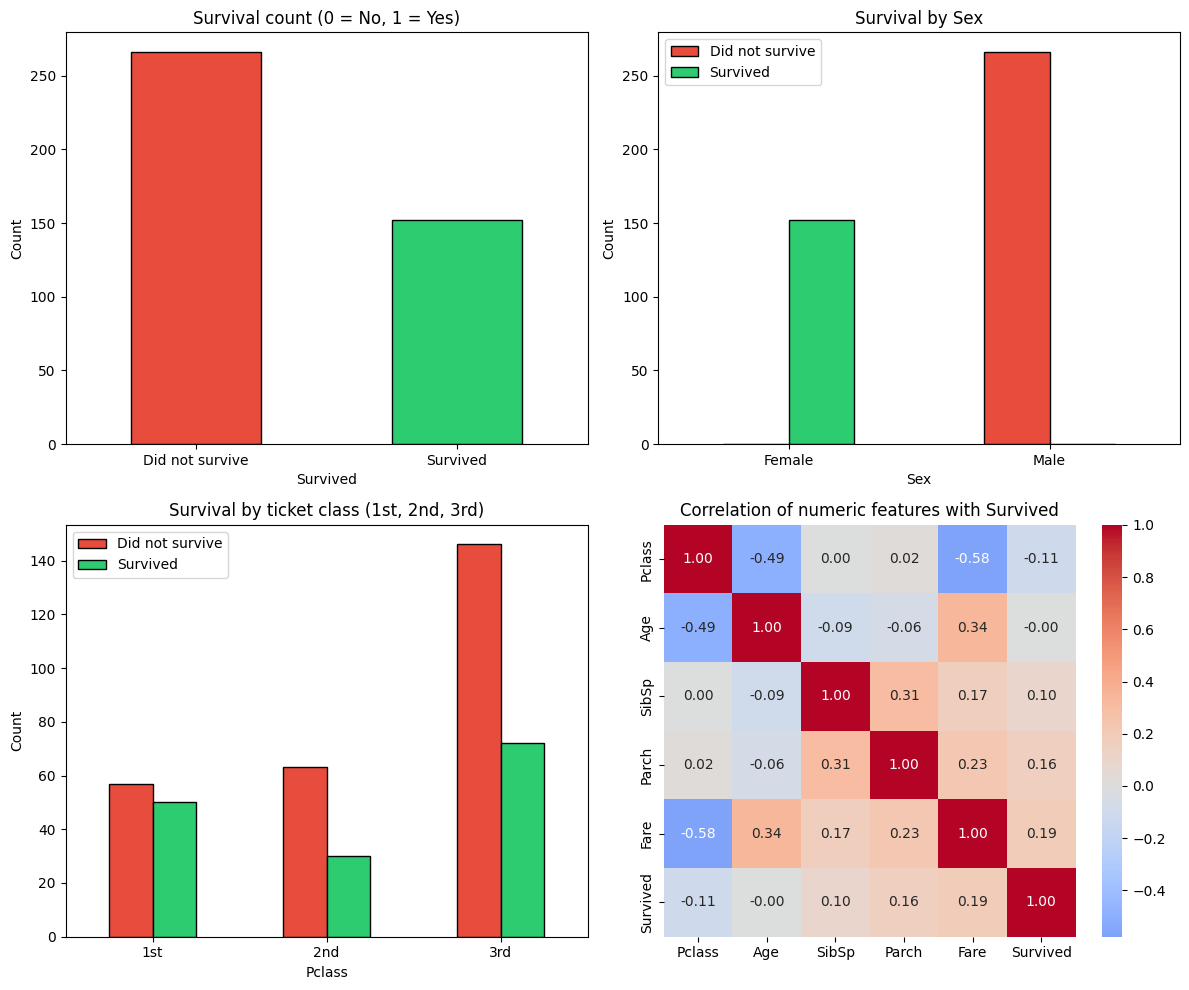

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Target balance
df['Survived'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0, 0].set_title('Survival count (0 = No, 1 = Yes)')
axes[0, 0].set_xticklabels(['Did not survive', 'Survived'], rotation=0)
axes[0, 0].set_ylabel('Count')

# 2. Survival by Sex
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', ax=axes[0, 1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0, 1].set_title('Survival by Sex')
axes[0, 1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0, 1].legend(['Did not survive', 'Survived'])
axes[0, 1].set_ylabel('Count')

# 3. Survival by Pclass
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar', ax=axes[1, 0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1, 0].set_title('Survival by ticket class (1st, 2nd, 3rd)')
axes[1, 0].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
axes[1, 0].legend(['Did not survive', 'Survived'])
axes[1, 0].set_ylabel('Count')

# 4. Correlation heatmap (numeric features used in model)
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 1], square=True)
axes[1, 1].set_title('Correlation of numeric features with Survived')

plt.tight_layout()
plt.show()

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## 2. Define features and target (no leakage)

We take only the columns we need and **do not** impute or encode yet. Imputation and encoding will be done **after** the train/test split using **training data only**, to avoid data leakage.

In [6]:
import pandas as pd

# Use .copy() to avoid SettingWithCopyWarning.
# Do NOT impute or encode on full data — that leaks test info. We'll do it after the split.
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
y = df['Survived'].copy()
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S
414,1,female,39.0,0,0,108.9000,C
415,3,male,38.5,0,0,7.2500,S
416,3,male,NaN,0,0,8.0500,S


### 2.1 Missing values

Count of missing values per feature. These will be filled after the split using **train** statistics only.

In [7]:
X.isna().sum()


Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

## 3. Train–test split

Split into 70% train and 30% test **before** any imputation or encoding. This keeps the test set completely unseen during preprocessing.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

## 4. Preprocessing (impute & encode from train only)

- **Impute** missing Age, Fare, Embarked using **medians/mode from the training set**.
- **One-hot encode** categoricals (Sex, Embarked) on train, then align test to the same columns (no extra categories from test).

In [9]:
# Impute and encode using TRAIN only (no data leakage)
age_median = X_train['Age'].median()
fare_median = X_train['Fare'].median()
embarked_mode = X_train['Embarked'].mode()[0]

X_train = X_train.copy()
X_test = X_test.copy()
X_train['Age'] = X_train['Age'].fillna(age_median)
X_train['Fare'] = X_train['Fare'].fillna(fare_median)
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_test['Age'] = X_test['Age'].fillna(age_median)
X_test['Fare'] = X_test['Fare'].fillna(fare_median)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

# One-hot encode: fit on train, align test to same columns
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## 5. Scale features

Fit `StandardScaler` on the **training set** only, then transform both train and test. Puts all features on a similar scale for the neural network.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Final safety check
import numpy as np
print(np.isnan(X_train).any(), np.isinf(X_train).any())

False False


### 5.1 Scaled training data (preview)

Scaled feature matrix passed to the neural network (zero mean, unit variance per feature).

In [11]:
X_train

array([[-1.47596812,  0.42426237, -0.50269793, ...,  0.78310898,
        -0.35082321, -1.31490378],
       [ 0.8727114 , -0.1818675 , -0.50269793, ...,  0.78310898,
         2.85043856, -1.31490378],
       [-1.47596812,  2.46995069,  0.5766241 , ..., -1.27696148,
        -0.35082321,  0.76051192],
       ...,
       [-1.47596812,  1.18192471, -0.50269793, ...,  0.78310898,
        -0.35082321, -1.31490378],
       [-0.30162836, -0.48493244, -0.50269793, ...,  0.78310898,
        -0.35082321,  0.76051192],
       [ 0.8727114 , -0.1818675 , -0.50269793, ...,  0.78310898,
         2.85043856, -1.31490378]], shape=(292, 8))

## 6. Neural network model

A small **feedforward network**: two hidden layers (16 and 8 units, ReLU) and a single output with **sigmoid** for binary classification (survived vs not).

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/opt/homebrew/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 7. Train the model

We train for 50 epochs with a 20% validation split from the training data. The `history` object stores loss and accuracy per epoch for plotting.

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3047 - loss: 0.7738 - val_accuracy: 0.3729 - val_loss: 0.7394
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4893 - loss: 0.7152 - val_accuracy: 0.4746 - val_loss: 0.6919
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5923 - loss: 0.6695 - val_accuracy: 0.5593 - val_loss: 0.6530
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6996 - loss: 0.6325 - val_accuracy: 0.6610 - val_loss: 0.6241
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7554 - loss: 0.6021 - val_accuracy: 0.6949 - val_loss: 0.5960
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7854 - loss: 0.5704 - val_accuracy: 0.7458 - val_loss: 0.5652
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8112 - loss: 0.5367 - val_accuracy: 0.7458 - val_loss: 0.5333
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8240 - loss: 0.5025 - val_accuracy: 0.7627 - val_loss

### 7.1 Training history (loss & accuracy)

Curves below show how **training** and **validation** loss/accuracy change over epochs. Validation metrics tell us how well the model generalizes; if validation loss starts rising while training loss falls, that suggests overfitting.

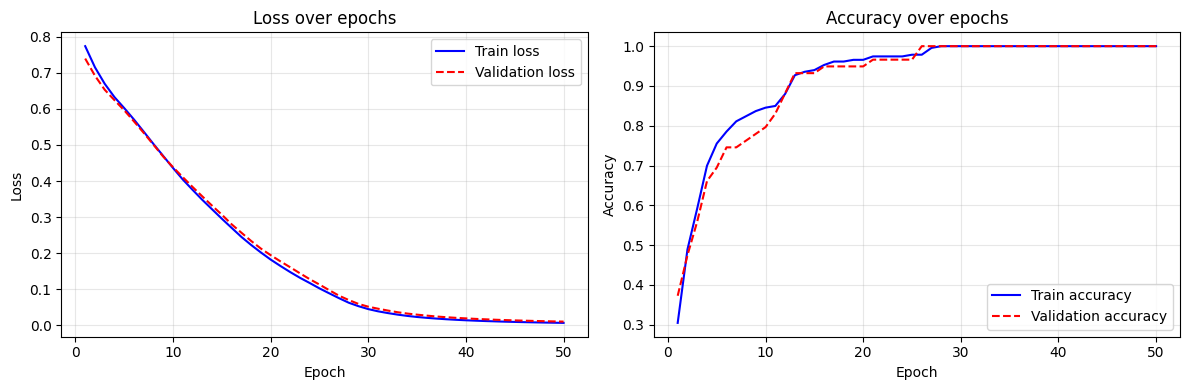

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history.history['accuracy']) + 1)
axes[0].plot(epochs, history.history['loss'], 'b-', label='Train loss')
axes[0].plot(epochs, history.history['val_loss'], 'r--', label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history.history['accuracy'], 'b-', label='Train accuracy')
axes[1].plot(epochs, history.history['val_accuracy'], 'r--', label='Validation accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluate on test set

Report loss and accuracy on the **held-out test set** (never used for training or preprocessing).

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0084 
Test Accuracy: 1.0


In [17]:
from sklearn.metrics import accuracy_score

# Convert probabilities → 0/1 labels
y_pred = (model.predict(X_test) > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Neural Network Accuracy:", accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Neural Network Accuracy: 1.0


### 8.1 Confusion matrix & ROC curve

- **Confusion matrix**: counts of true positives, false positives, true negatives, false negatives. Diagonal = correct predictions.
- **ROC curve**: true positive rate vs false positive rate at different thresholds. **AUC** = area under the curve (1.0 = perfect classifier).

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


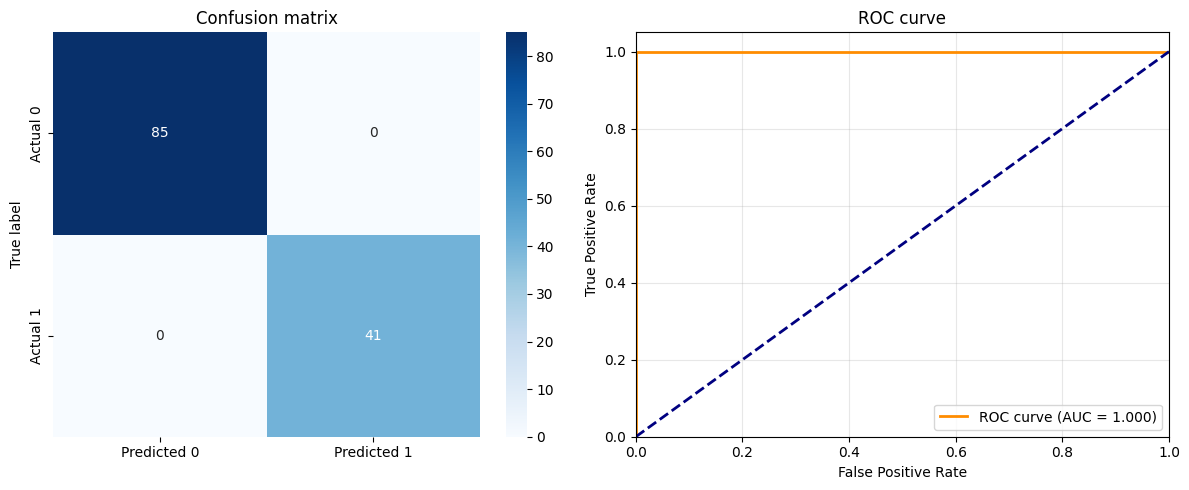

In [18]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred_proba = model.predict(X_test).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Confusion matrix')
axes[0].set_ylabel('True label')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
y_pred = model.predict(X_test)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


array([[0.00253781],
       [0.9941067 ],
       [0.00759911],
       [0.00128962],
       [0.9935585 ],
       [0.015462  ],
       [0.9927975 ],
       [0.0060304 ],
       [0.9953681 ],
       [0.00103527],
       [0.00667875],
       [0.99474186],
       [0.9846061 ],
       [0.98665494],
       [0.00103527],
       [0.00109205],
       [0.9929462 ],
       [0.00700162],
       [0.00113537],
       [0.00789259],
       [0.00624028],
       [0.02418031],
       [0.9906768 ],
       [0.00198247],
       [0.99059266],
       [0.9954291 ],
       [0.9828544 ],
       [0.00551151],
       [0.00285158],
       [0.00198247],
       [0.00109274],
       [0.99147916],
       [0.99350345],
       [0.00103527],
       [0.99513775],
       [0.00197695],
       [0.99516594],
       [0.00644281],
       [0.9849914 ],
       [0.00559948],
       [0.99516594],
       [0.98145294],
       [0.0085742 ],
       [0.00491499],
       [0.00557967],
       [0.00108515],
       [0.98118347],
       [0.974